# 🔥 Notebook 03 — Modèle Baseline

## Objectif
Entraîner un premier modèle prédictif du temps de réponse LFB à partir du silver v2 (40 features, 1.8M lignes, 17 ans).

## Méthodologie
1. **Split temporel** (jamais aléatoire — data leakage garanti sinon)
2. **Baseline naïve** = médiane globale → référence à battre
3. **LightGBM** = premier modèle sérieux
4. **Métriques** : RMSE, MAE, R², MAPE
5. **Feature importance** → validation des intuitions du feature engineering

## Contraintes
- ⚠️ **Pas de data leakage** : les target encodings doivent être recalculés uniquement sur le train
- ⚠️ **Split temporel strict** : simuler la vraie contrainte opérationnelle (prédire le futur avec le passé)

In [2]:
"""
=== SETUP NOTEBOOK 03 ===
"""

import pandas as pd
import numpy as np
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Chemins
project_root  = Path('..').resolve()
PROCESSED_DIR = project_root / 'data' / 'processed'
REPORTS_DIR   = project_root / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

# Rechargement silver v2
print("📂 Chargement silver v2...")
start = time.time()
df = pd.read_parquet(PROCESSED_DIR / 'lfb_features_v2.parquet')
print(f"✅ Chargé en {time.time()-start:.1f}s — {df.shape}")

# Récap
print(f"\n=== Répartition annuelle ===")
print(df['CalYear'].value_counts().sort_index())
print(f"\nTarget médiane : {df['AttendanceTimeMinutes'].median():.2f} min")

📂 Chargement silver v2...
✅ Chargé en 0.9s — (1816534, 57)

=== Répartition annuelle ===
CalYear
2009    120464
2010    109587
2011    101955
2012     95982
2013     92423
2014     86987
2015     89515
2016     96865
2017     96313
2018     98610
2019     98073
2020     92709
2021    101727
2022    117698
2023    118908
2024    126296
2025    130107
2026     42315
Name: count, dtype: int64

Target médiane : 4.98 min


In [3]:
"""
=== SPLIT TEMPOREL ===
⚠️ CRITIQUE : jamais de split aléatoire sur des données temporelles.
On simule la vraie contrainte : prédire le futur à partir du passé.
"""

# Split par année
train = df[df['year'] <= 2020].copy()
val   = df[df['year'].between(2021, 2023)].copy()
test  = df[df['year'] >= 2024].copy()

print(f"=== SPLIT TEMPOREL ===")
print(f"Train (2009-2020) : {len(train):,} lignes ({len(train)/len(df)*100:.1f}%)")
print(f"Val   (2021-2023) : {len(val):,} lignes ({len(val)/len(df)*100:.1f}%)")
print(f"Test  (2024-2026) : {len(test):,} lignes ({len(test)/len(df)*100:.1f}%)")
print(f"Total             : {len(train)+len(val)+len(test):,} lignes")

# Distribution target par split
print(f"\n=== Target moyenne par split ===")
print(f"Train : {train['AttendanceTimeMinutes'].mean():.2f} min")
print(f"Val   : {val['AttendanceTimeMinutes'].mean():.2f} min")
print(f"Test  : {test['AttendanceTimeMinutes'].mean():.2f} min")

=== SPLIT TEMPOREL ===
Train (2009-2020) : 1,179,483 lignes (64.9%)
Val   (2021-2023) : 338,333 lignes (18.6%)
Test  (2024-2026) : 298,718 lignes (16.4%)
Total             : 1,816,534 lignes

=== Target moyenne par split ===
Train : 5.35 min
Val   : 5.31 min
Test  : 5.49 min


In [4]:
"""
=== BASELINE NAÏVE ===
Modèle "sans intelligence" = prédire toujours la médiane du train.
C'est LE score minimum que n'importe quel modèle doit battre.
"""

median_train = train['AttendanceTimeMinutes'].median()
print(f"Médiane du train : {median_train:.2f} min\n")

# Prédictions naïves = médiane pour tous
y_val_pred_naive  = np.full(len(val), median_train)
y_test_pred_naive = np.full(len(test), median_train)

def eval_model(y_true, y_pred, name=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"=== {name} ===")
    print(f"  MAE  : {mae:.3f} min ({mae*60:.0f} sec)")
    print(f"  RMSE : {rmse:.3f} min ({rmse*60:.0f} sec)")
    print(f"  R²   : {r2:+.4f}")
    print(f"  MAPE : {mape:.1f}%")
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}

results = {}
results['baseline_val']  = eval_model(val['AttendanceTimeMinutes'],  y_val_pred_naive,  "BASELINE NAÏVE - VALIDATION")
print()
results['baseline_test'] = eval_model(test['AttendanceTimeMinutes'], y_test_pred_naive, "BASELINE NAÏVE - TEST")

Médiane du train : 4.95 min

=== BASELINE NAÏVE - VALIDATION ===
  MAE  : 1.575 min (95 sec)
  RMSE : 2.221 min (133 sec)
  R²   : -0.0275
  MAPE : 34.8%

=== BASELINE NAÏVE - TEST ===
  MAE  : 1.626 min (98 sec)
  RMSE : 2.296 min (138 sec)
  R²   : -0.0590
  MAPE : 33.5%


In [5]:
"""
=== ANTI-LEAKAGE : recalcul des target encodings sur le TRAIN uniquement ===
Puis on applique les mêmes mappings à val et test.
"""

# Colonnes catégorielles à encoder
encode_map = {
    'borough': 'borough_target_enc',
    'Postcode_district': 'postcode_target_enc',
    'IncidentGroup': 'incident_group_target_enc',
    'PropertyCategory': 'property_cat_target_enc',
    'AddressQualifier': 'address_qual_target_enc',
}

for cat_col, feat_col in encode_map.items():
    # Calcul de la moyenne UNIQUEMENT sur le train
    mapping = train.groupby(cat_col)['AttendanceTimeMinutes'].mean()
    global_mean = train['AttendanceTimeMinutes'].mean()
    
    # Application aux 3 splits (val/test : valeurs inconnues → moyenne globale train)
    train[feat_col] = train[cat_col].map(mapping).fillna(global_mean)
    val[feat_col]   = val[cat_col].map(mapping).fillna(global_mean)
    test[feat_col]  = test[cat_col].map(mapping).fillna(global_mean)
    
    print(f"✅ {feat_col} recalculé sur train (mean={global_mean:.2f}, {len(mapping)} catégories)")

# Idem pour borough_freq (frequency encoding)
borough_freq_train = train['borough'].value_counts()
train['borough_freq'] = train['borough'].map(borough_freq_train).fillna(0)
val['borough_freq']   = val['borough'].map(borough_freq_train).fillna(0)
test['borough_freq']  = test['borough'].map(borough_freq_train).fillna(0)
print(f"✅ borough_freq recalculé sur train")

print(f"\n🎯 Anti-leakage OK — target encodings basés uniquement sur 2009-2020")

✅ borough_target_enc recalculé sur train (mean=5.35, 33 catégories)
✅ postcode_target_enc recalculé sur train (mean=5.35, 322 catégories)
✅ incident_group_target_enc recalculé sur train (mean=5.35, 3 catégories)
✅ property_cat_target_enc recalculé sur train (mean=5.35, 9 catégories)
✅ address_qual_target_enc recalculé sur train (mean=5.35, 11 catégories)
✅ borough_freq recalculé sur train

🎯 Anti-leakage OK — target encodings basés uniquement sur 2009-2020


In [6]:
"""
=== PRÉPARATION FEATURES POUR LE MODÈLE ===
"""

# Toutes les features ML (40)
feature_cols = [
    # Temporelles (17)
    'hour', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year',
    'is_weekend', 'is_night', 'is_rush_hour', 'is_summer', 'is_winter',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    # Géographiques (4)
    'borough_target_enc', 'borough_freq', 'is_inner_london', 'postcode_target_enc',
    # Distance (3)
    'dist_nearest_station_km', 'dist_top3_stations_km', 'n_stations_within_3km',
    # Incident (3)
    'incident_group_target_enc', 'property_cat_target_enc', 'address_qual_target_enc',
    # Météo (5)
    'temp_max', 'precip_mm', 'snow_cm', 'is_heatwave', 'is_freezing',
    # Population (4)
    'pop_total', 'pop_density_per_hectare', 'borough_area_km2', 'pop_growth_5y_pct',
    # Holidays (4)
    'is_holiday', 'is_day_before_holiday', 'is_day_after_holiday', 'days_until_next_holiday',
]

# Vérif des colonnes disponibles
missing = [c for c in feature_cols if c not in train.columns]
if missing:
    print(f"⚠️ Colonnes manquantes : {missing}")
feature_cols = [c for c in feature_cols if c in train.columns]

# Préparation X / y
X_train, y_train = train[feature_cols], train['AttendanceTimeMinutes']
X_val,   y_val   = val[feature_cols],   val['AttendanceTimeMinutes']
X_test,  y_test  = test[feature_cols],  test['AttendanceTimeMinutes']

# Gestion NaN (on remplit par la moyenne du train)
for col in feature_cols:
    if X_train[col].isna().any() or X_val[col].isna().any() or X_test[col].isna().any():
        mean_val = X_train[col].mean()
        X_train[col] = X_train[col].fillna(mean_val)
        X_val[col]   = X_val[col].fillna(mean_val)
        X_test[col]  = X_test[col].fillna(mean_val)

print(f"✅ Features prêtes : {len(feature_cols)}")
print(f"   X_train : {X_train.shape}")
print(f"   X_val   : {X_val.shape}")
print(f"   X_test  : {X_test.shape}")

# Vérif finale : aucun NaN
print(f"\nNaN dans X_train : {X_train.isna().sum().sum()}")
print(f"NaN dans X_val   : {X_val.isna().sum().sum()}")
print(f"NaN dans X_test  : {X_test.isna().sum().sum()}")

✅ Features prêtes : 40
   X_train : (1179483, 40)
   X_val   : (338333, 40)
   X_test  : (298718, 40)

NaN dans X_train : 0
NaN dans X_val   : 0
NaN dans X_test  : 0


In [7]:
"""
=== MODÈLE #1 : LightGBM ===
Gradient boosting rapide et performant sur tabulaire.
"""

import lightgbm as lgb

print("🚀 Entraînement LightGBM...")
start = time.time()

# Datasets LightGBM (format optimisé)
train_data = lgb.Dataset(X_train, label=y_train)
val_data   = lgb.Dataset(X_val,   label=y_val, reference=train_data)

# Hyperparamètres raisonnables pour un baseline
params = {
    'objective': 'regression',
    'metric': ['mae', 'rmse'],
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_data_in_leaf': 100,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq': 5,
    'verbose': -1,
    'n_jobs': -1,
}

# Entraînement avec early stopping
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50),
    ]
)

elapsed = time.time() - start
print(f"\n✅ Entraînement terminé en {elapsed:.0f}s")
print(f"   Nombre d'arbres optimal : {model.best_iteration}")

🚀 Entraînement LightGBM...
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 1.41374	train's rmse: 2.05294	val's l1: 1.38075	val's rmse: 1.99451
[100]	train's l1: 1.38869	train's rmse: 2.02703	val's l1: 1.35309	val's rmse: 1.99047
[150]	train's l1: 1.37569	train's rmse: 2.01374	val's l1: 1.34205	val's rmse: 1.98709
[200]	train's l1: 1.36756	train's rmse: 2.00509	val's l1: 1.33571	val's rmse: 1.98448
[250]	train's l1: 1.36022	train's rmse: 1.99771	val's l1: 1.32932	val's rmse: 1.98029
[300]	train's l1: 1.35543	train's rmse: 1.99252	val's l1: 1.32538	val's rmse: 1.978
[350]	train's l1: 1.35058	train's rmse: 1.98706	val's l1: 1.32127	val's rmse: 1.97531
[400]	train's l1: 1.34569	train's rmse: 1.98214	val's l1: 1.31711	val's rmse: 1.97225
[450]	train's l1: 1.3423	train's rmse: 1.97804	val's l1: 1.31489	val's rmse: 1.97071
[500]	train's l1: 1.33869	train's rmse: 1.97399	val's l1: 1.31259	val's rmse: 1.96884
[550]	train's l1: 1.33613	train's rmse: 1.9707	val's l1:

In [8]:
"""
=== ÉVALUATION LightGBM ===
Comparaison avec la baseline naïve.
"""

# Prédictions
y_val_pred_lgb  = model.predict(X_val,  num_iteration=model.best_iteration)
y_test_pred_lgb = model.predict(X_test, num_iteration=model.best_iteration)

results['lgb_val']  = eval_model(y_val,  y_val_pred_lgb,  "LightGBM - VALIDATION")
print()
results['lgb_test'] = eval_model(y_test, y_test_pred_lgb, "LightGBM - TEST")

# Comparaison
print(f"\n=== COMPARAISON BASELINE vs LightGBM ===")
print(f"{'Metric':<10} {'Baseline Val':<15} {'LightGBM Val':<15} {'Gain %':<10} {'Baseline Test':<15} {'LightGBM Test':<15} {'Gain %':<10}")
for metric in ['mae', 'rmse', 'r2', 'mape']:
    b_val = results['baseline_val'][metric]
    l_val = results['lgb_val'][metric]
    b_test = results['baseline_test'][metric]
    l_test = results['lgb_test'][metric]
    if metric == 'r2':
        gain_val = f"+{l_val - b_val:.3f}"
        gain_test = f"+{l_test - b_test:.3f}"
    else:
        gain_val = f"{(l_val - b_val) / b_val * 100:+.1f}%"
        gain_test = f"{(l_test - b_test) / b_test * 100:+.1f}%"
    print(f"{metric.upper():<10} {b_val:<15.3f} {l_val:<15.3f} {gain_val:<10} {b_test:<15.3f} {l_test:<15.3f} {gain_test:<10}")

=== LightGBM - VALIDATION ===
  MAE  : 1.303 min (78 sec)
  RMSE : 1.963 min (118 sec)
  R²   : +0.1969
  MAPE : 27.9%

=== LightGBM - TEST ===
  MAE  : 1.354 min (81 sec)
  RMSE : 2.044 min (123 sec)
  R²   : +0.1606
  MAPE : 27.1%

=== COMPARAISON BASELINE vs LightGBM ===
Metric     Baseline Val    LightGBM Val    Gain %     Baseline Test   LightGBM Test   Gain %    
MAE        1.575           1.303           -17.3%     1.626           1.354           -16.7%    
RMSE       2.221           1.963           -11.6%     2.296           2.044           -11.0%    
R2         -0.028          0.197           +0.224     -0.059          0.161           +0.220    
MAPE       34.769          27.873          -19.8%     33.462          27.129          -18.9%    


=== TOP 20 FEATURES par IMPORTANCE ===
                  feature  importance   pct  cum_pct
  dist_nearest_station_km  8109243.48 48.57    48.57
      postcode_target_enc  2301245.12 13.78    62.35
    dist_top3_stations_km   839962.36  5.03    67.38
  address_qual_target_enc   592446.29  3.55    70.93
  property_cat_target_enc   544126.59  3.26    74.19
                     year   509078.34  3.05    77.24
incident_group_target_enc   494944.79  2.96    80.21
                     hour   488957.54  2.93    83.13
    n_stations_within_3km   282776.04  1.69    84.83
             borough_freq   275004.29  1.65    86.48
                pop_total   246184.14  1.47    87.95
  pop_density_per_hectare   245441.84  1.47    89.42
        pop_growth_5y_pct   224868.29  1.35    90.77
       borough_target_enc   210697.50  1.26    92.03
                 temp_max   179693.02  1.08    93.11
                 hour_cos   154676.03  0.93    94.03
  days_until_next_holiday   145630.07  0.87    94.90
       

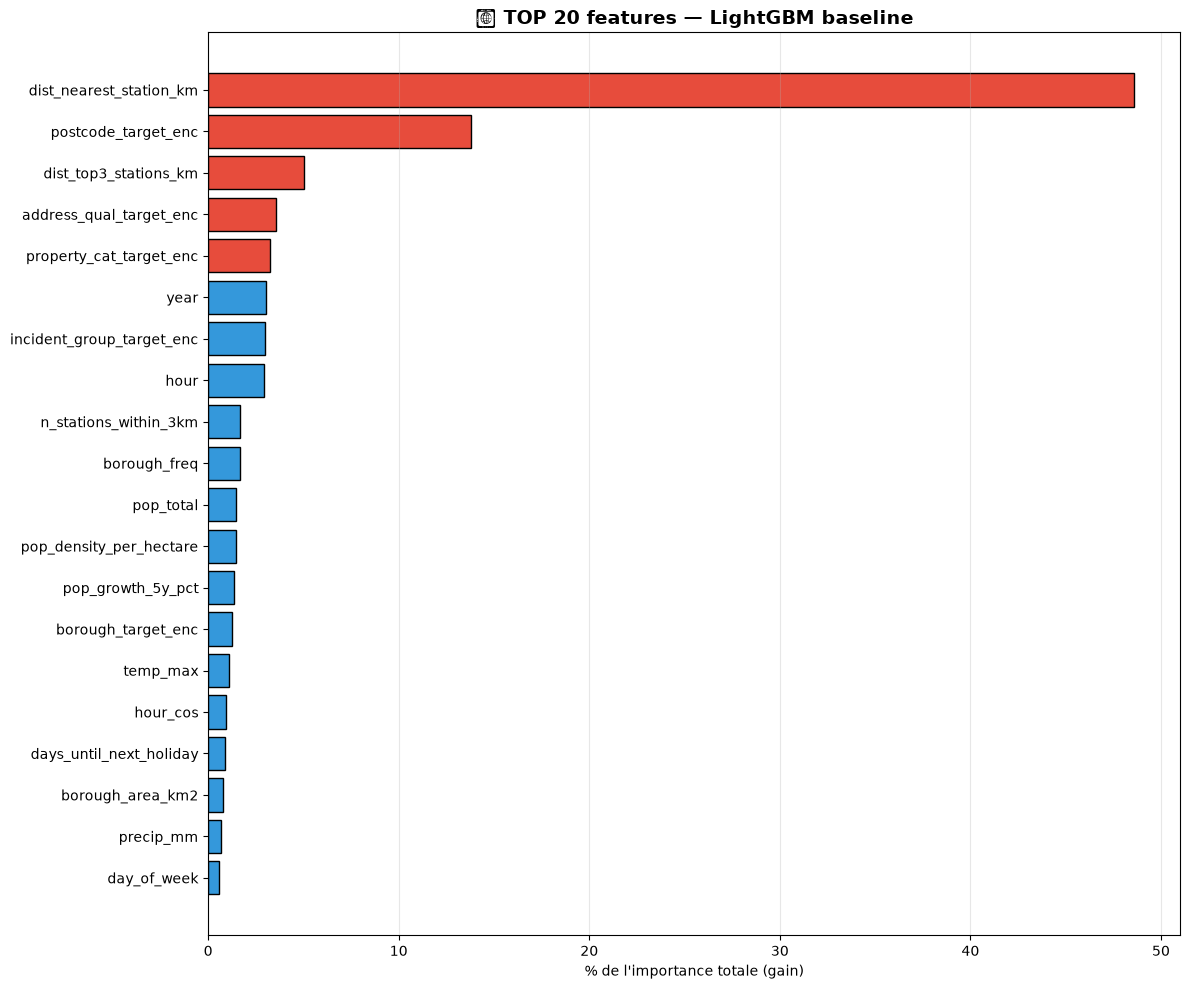

In [9]:
"""
=== FEATURE IMPORTANCE ===
Quelles features contribuent le plus aux prédictions ?
"""

import matplotlib.pyplot as plt

# Importance basée sur le gain (meilleure qualitativement que 'split')
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)

# Ajout du % relatif
importance['pct'] = importance['importance'] / importance['importance'].sum() * 100
importance['cum_pct'] = importance['pct'].cumsum()

print(f"=== TOP 20 FEATURES par IMPORTANCE ===")
print(importance.head(20).round(2).to_string(index=False))

print(f"\n=== TOP 10 = {importance.head(10)['pct'].sum():.1f}% de l'importance ===")
print(f"=== TOP 20 = {importance.head(20)['pct'].sum():.1f}% de l'importance ===")

# Visualisation
fig, ax = plt.subplots(figsize=(12, 10))
top20 = importance.head(20).iloc[::-1]
colors = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(top20))][::-1]
ax.barh(top20['feature'], top20['pct'], color=colors, edgecolor='black')
ax.set_xlabel('% de l\'importance totale (gain)')
ax.set_title('🎯 TOP 20 features — LightGBM baseline', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'feature_importance_baseline.png', dpi=100, bbox_inches='tight')
plt.show()

In [10]:
"""
=== LightGBM V2 — Modèle mieux entraîné ===
Objectif : converger vraiment cette fois.
Changements : LR 0.05 → 0.02, arbres 1000 → 5000, num_leaves 63 → 127
"""

print("🚀 Entraînement LightGBM V2 (converge cette fois)...")
start = time.time()

train_data = lgb.Dataset(X_train, label=y_train)
val_data   = lgb.Dataset(X_val,   label=y_val, reference=train_data)

params_v2 = {
    'objective': 'regression',
    'metric': ['mae', 'rmse'],
    'learning_rate': 0.02,          # ← plus bas
    'num_leaves': 127,              # ← plus de capacité
    'max_depth': -1,
    'min_data_in_leaf': 50,         # ← plus fin
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq': 5,
    'lambda_l1': 0.1,               # ← régularisation légère
    'lambda_l2': 0.1,
    'verbose': -1,
    'n_jobs': -1,
}

model_v2 = lgb.train(
    params_v2,
    train_data,
    num_boost_round=5000,           # ← 5x plus d'arbres
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),  # ← plus de patience
        lgb.log_evaluation(period=100),
    ]
)

elapsed = time.time() - start
print(f"\n✅ Entraînement V2 en {elapsed:.0f}s")
print(f"   Nombre d'arbres optimal : {model_v2.best_iteration}")

# Évaluation
y_val_pred_v2  = model_v2.predict(X_val,  num_iteration=model_v2.best_iteration)
y_test_pred_v2 = model_v2.predict(X_test, num_iteration=model_v2.best_iteration)

print()
results['lgb_v2_val']  = eval_model(y_val,  y_val_pred_v2,  "LightGBM V2 - VALIDATION")
print()
results['lgb_v2_test'] = eval_model(y_test, y_test_pred_v2, "LightGBM V2 - TEST")

# Comparaison v1 vs v2
print(f"\n=== V1 vs V2 (Validation) ===")
print(f"MAE  : {results['lgb_val']['mae']:.3f} → {results['lgb_v2_val']['mae']:.3f}  ({(results['lgb_v2_val']['mae']-results['lgb_val']['mae'])/results['lgb_val']['mae']*100:+.1f}%)")
print(f"RMSE : {results['lgb_val']['rmse']:.3f} → {results['lgb_v2_val']['rmse']:.3f}  ({(results['lgb_v2_val']['rmse']-results['lgb_val']['rmse'])/results['lgb_val']['rmse']*100:+.1f}%)")
print(f"R²   : {results['lgb_val']['r2']:.3f} → {results['lgb_v2_val']['r2']:.3f}  ({results['lgb_v2_val']['r2']-results['lgb_val']['r2']:+.3f})")


🚀 Entraînement LightGBM V2 (converge cette fois)...
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.41222	train's rmse: 2.05071	val's l1: 1.38145	val's rmse: 1.99206
[200]	train's l1: 1.38071	train's rmse: 2.01902	val's l1: 1.34872	val's rmse: 1.98425
[300]	train's l1: 1.36658	train's rmse: 2.00314	val's l1: 1.3385	val's rmse: 1.98379
[400]	train's l1: 1.35611	train's rmse: 1.99164	val's l1: 1.33098	val's rmse: 1.98037
[500]	train's l1: 1.34832	train's rmse: 1.98283	val's l1: 1.32569	val's rmse: 1.97752
[600]	train's l1: 1.34189	train's rmse: 1.9753	val's l1: 1.32105	val's rmse: 1.97452
[700]	train's l1: 1.33651	train's rmse: 1.96883	val's l1: 1.31753	val's rmse: 1.97217
[800]	train's l1: 1.33207	train's rmse: 1.96308	val's l1: 1.31513	val's rmse: 1.97064
[900]	train's l1: 1.32797	train's rmse: 1.95785	val's l1: 1.31309	val's rmse: 1.96936
[1000]	train's l1: 1.32374	train's rmse: 1.95237	val's l1: 1.3109	val's rmse: 1.9681
[1100]	train's l1: 1.32008	tr

=== Distribution des erreurs (validation) ===
count    338333.00
mean          1.30
std           1.47
min           0.00
25%           0.41
50%           0.88
75%           1.59
max          16.09
Name: abs_error, dtype: float64

=== TOP 10 boroughs LES PLUS DIFFICILES ===
                       mae      n  true_mean  pred_mean
borough                                                
HILLINGDON            1.49  10852       6.29       6.06
HAVERING              1.47   7326       6.03       5.87
ENFIELD               1.45  10363       6.02       5.73
REDBRIDGE             1.45   7655       5.84       5.48
WALTHAM FOREST        1.43   9047       5.11       4.85
EALING                1.42  11932       5.58       5.29
KINGSTON UPON THAMES  1.42   4284       5.47       5.35
RICHMOND UPON THAMES  1.40   5536       5.76       5.42
HARROW                1.39   5892       5.83       5.62
HOUNSLOW              1.39   9071       5.69       5.44

=== TOP 10 boroughs LES PLUS FACILES ===
           

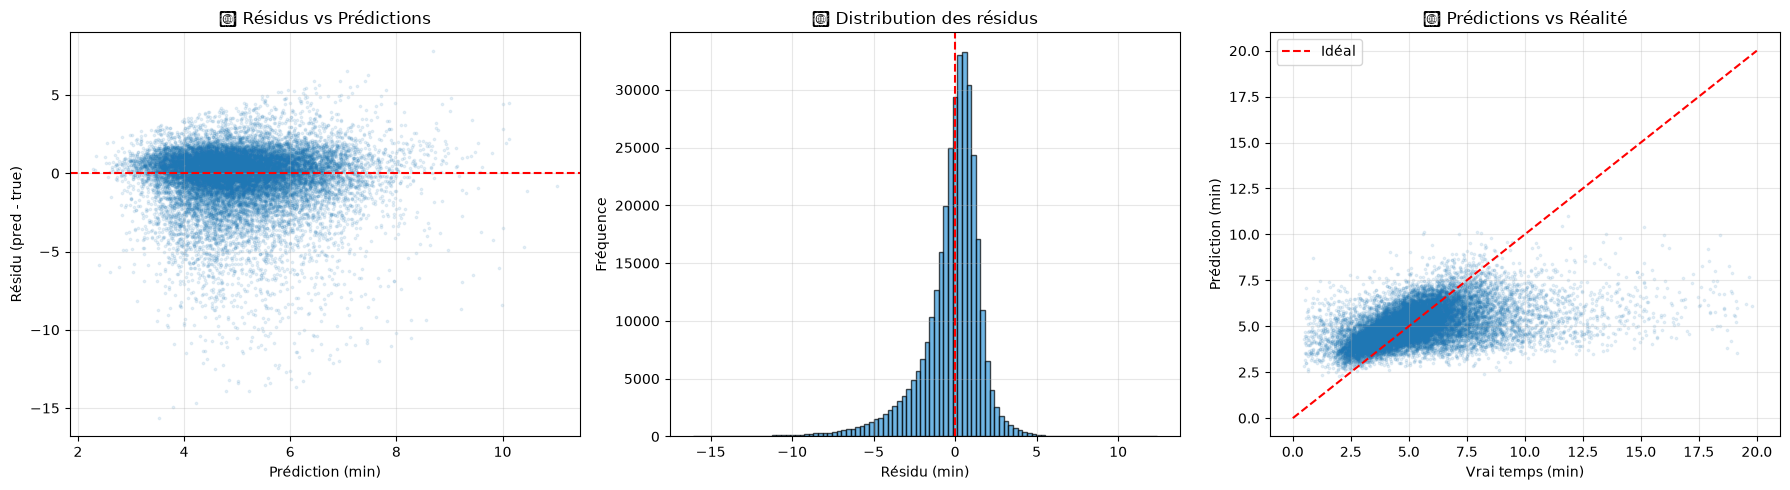

In [11]:
"""
=== ANALYSE D'ERREURS ===
Où le modèle se plante-t-il le plus ?
"""

import matplotlib.pyplot as plt

# Ajout des prédictions au dataset validation
val_analysis = val.copy()
val_analysis['pred']   = y_val_pred_v2
val_analysis['error']  = val_analysis['pred'] - val_analysis['AttendanceTimeMinutes']
val_analysis['abs_error'] = val_analysis['error'].abs()

# --- 1. Distribution des erreurs ---
print(f"=== Distribution des erreurs (validation) ===")
print(val_analysis['abs_error'].describe().round(2))

# --- 2. Erreur par borough ---
print(f"\n=== TOP 10 boroughs LES PLUS DIFFICILES ===")
by_borough = val_analysis.groupby('borough').agg(
    mae=('abs_error', 'mean'),
    n=('abs_error', 'count'),
    true_mean=('AttendanceTimeMinutes', 'mean'),
    pred_mean=('pred', 'mean')
).round(2).sort_values('mae', ascending=False)
print(by_borough.head(10))

print(f"\n=== TOP 10 boroughs LES PLUS FACILES ===")
print(by_borough.tail(10))

# --- 3. Erreur par heure ---
print(f"\n=== Erreur par heure ===")
by_hour = val_analysis.groupby('hour').agg(
    mae=('abs_error', 'mean'),
    n=('abs_error', 'count')
).round(2)
print(by_hour)

# --- 4. Erreur par type d'incident ---
print(f"\n=== Erreur par type d'incident ===")
print(val_analysis.groupby('IncidentGroup').agg(
    mae=('abs_error', 'mean'),
    n=('abs_error', 'count'),
    true_mean=('AttendanceTimeMinutes', 'mean'),
    pred_mean=('pred', 'mean')
).round(2))

# --- 5. Visualisation résidus ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Résidus vs prédictions
axes[0].scatter(val_analysis['pred'].sample(20000, random_state=42),
                val_analysis['error'].sample(20000, random_state=42),
                alpha=0.1, s=3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Prédiction (min)')
axes[0].set_ylabel('Résidu (pred - true)')
axes[0].set_title('📊 Résidus vs Prédictions')
axes[0].grid(True, alpha=0.3)

# Distribution des résidus
axes[1].hist(val_analysis['error'], bins=100, edgecolor='black', alpha=0.7, color='#3498db')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Résidu (min)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('📊 Distribution des résidus')
axes[1].grid(True, alpha=0.3)

# True vs Predicted
sample = val_analysis.sample(20000, random_state=42)
axes[2].scatter(sample['AttendanceTimeMinutes'], sample['pred'], alpha=0.1, s=3)
axes[2].plot([0, 20], [0, 20], 'r--', label='Idéal')
axes[2].set_xlabel('Vrai temps (min)')
axes[2].set_ylabel('Prédiction (min)')
axes[2].set_title('🎯 Prédictions vs Réalité')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'error_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

In [12]:
"""
=== FEATURES HISTORIQUES AGRÉGÉES ===
Ta grande intuition du début ! Calculées SUR TRAIN UNIQUEMENT (anti-leakage).
"""

print("🔧 Calcul features historiques agrégées sur TRAIN...")

# === Feature 1 : temps moyen historique par borough × hour ===
hist_borough_hour = train.groupby(['borough', 'hour'])['AttendanceTimeMinutes'].mean()
hist_borough_hour.name = 'hist_borough_hour_mean'

# === Feature 2 : temps moyen historique par borough × hour × mois ===
hist_borough_hour_month = train.groupby(['borough', 'hour', 'month'])['AttendanceTimeMinutes'].mean()
hist_borough_hour_month.name = 'hist_borough_hour_month_mean'

# === Feature 3 : nombre d'incidents historiques par borough × hour (charge du réseau) ===
hist_borough_hour_count = train.groupby(['borough', 'hour']).size() / train['year'].nunique()  # avg par an
hist_borough_hour_count.name = 'hist_borough_hour_incidents_per_year'

# === Feature 4 : temps moyen par postcode × hour (granularité fine) ===
hist_postcode_hour = train.groupby(['Postcode_district', 'hour'])['AttendanceTimeMinutes'].mean()
hist_postcode_hour.name = 'hist_postcode_hour_mean'

# --- Application aux 3 splits ---
global_mean = train['AttendanceTimeMinutes'].mean()

for split_df, name in [(train, 'train'), (val, 'val'), (test, 'test')]:
    # Feature 1 : borough × hour
    split_df['hist_borough_hour_mean'] = split_df.set_index(['borough', 'hour']).index.map(hist_borough_hour).fillna(global_mean)
    
    # Feature 2 : borough × hour × month
    split_df['hist_borough_hour_month_mean'] = split_df.set_index(['borough', 'hour', 'month']).index.map(hist_borough_hour_month).fillna(global_mean)
    
    # Feature 3 : charge historique borough × hour
    split_df['hist_borough_hour_incidents_per_year'] = split_df.set_index(['borough', 'hour']).index.map(hist_borough_hour_count).fillna(0)
    
    # Feature 4 : postcode × hour
    split_df['hist_postcode_hour_mean'] = split_df.set_index(['Postcode_district', 'hour']).index.map(hist_postcode_hour).fillna(global_mean)
    
    print(f"  ✅ {name}: 4 features historiques ajoutées")

# Corrélations
print(f"\n=== CORRÉLATIONS FEATURES HISTORIQUES ↔ target (validation) ===")
for col in ['hist_borough_hour_mean', 'hist_borough_hour_month_mean',
            'hist_borough_hour_incidents_per_year', 'hist_postcode_hour_mean']:
    corr = val[col].corr(val['AttendanceTimeMinutes'])
    print(f"  {col:<45} : {corr:+.4f}")

🔧 Calcul features historiques agrégées sur TRAIN...
  ✅ train: 4 features historiques ajoutées
  ✅ val: 4 features historiques ajoutées
  ✅ test: 4 features historiques ajoutées

=== CORRÉLATIONS FEATURES HISTORIQUES ↔ target (validation) ===
  hist_borough_hour_mean                        : +0.2271
  hist_borough_hour_month_mean                  : +0.2199
  hist_borough_hour_incidents_per_year          : -0.0499
  hist_postcode_hour_mean                       : +0.3183


In [14]:
"""
=== LightGBM V3 avec features historiques ===
"""

# Ajout des nouvelles features
new_features = ['hist_borough_hour_mean', 'hist_borough_hour_month_mean',
                'hist_borough_hour_incidents_per_year', 'hist_postcode_hour_mean']
feature_cols_v3 = feature_cols + new_features

X_train_v3 = train[feature_cols_v3]
X_val_v3   = val[feature_cols_v3]
X_test_v3  = test[feature_cols_v3]

print(f"✅ {len(feature_cols_v3)} features (dont {len(new_features)} nouvelles)")

# Entraînement
print(f"\n🚀 Entraînement V3 (44 features)...")
start = time.time()

train_data_v3 = lgb.Dataset(X_train_v3, label=y_train)
val_data_v3   = lgb.Dataset(X_val_v3,   label=y_val, reference=train_data_v3)

model_v3 = lgb.train(
    params_v2,  # mêmes hyperparams que V2
    train_data_v3,
    num_boost_round=3000,
    valid_sets=[train_data_v3, val_data_v3],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
)

elapsed = time.time() - start
print(f"\n✅ Entraînement V3 en {elapsed:.0f}s — {model_v3.best_iteration} arbres")

# Évaluation
y_val_pred_v3  = model_v3.predict(X_val_v3,  num_iteration=model_v3.best_iteration)
y_test_pred_v3 = model_v3.predict(X_test_v3, num_iteration=model_v3.best_iteration)

print()
results['lgb_v3_val']  = eval_model(y_val,  y_val_pred_v3,  "LightGBM V3 - VALIDATION")
print()
results['lgb_v3_test'] = eval_model(y_test, y_test_pred_v3, "LightGBM V3 - TEST")

# Comparaison V2 vs V3
print(f"\n=== V2 vs V3 (Validation) ===")
print(f"MAE  : {results['lgb_v2_val']['mae']:.3f} → {results['lgb_v3_val']['mae']:.3f}  ({(results['lgb_v3_val']['mae']-results['lgb_v2_val']['mae'])/results['lgb_v2_val']['mae']*100:+.1f}%)")
print(f"RMSE : {results['lgb_v2_val']['rmse']:.3f} → {results['lgb_v3_val']['rmse']:.3f}  ({(results['lgb_v3_val']['rmse']-results['lgb_v2_val']['rmse'])/results['lgb_v2_val']['rmse']*100:+.1f}%)")
print(f"R²   : {results['lgb_v2_val']['r2']:.3f} → {results['lgb_v3_val']['r2']:.3f}  ({results['lgb_v3_val']['r2']-results['lgb_v2_val']['r2']:+.3f})")

# Feature importance V3
print(f"\n=== TOP 15 features V3 ===")
importance_v3 = pd.DataFrame({
    'feature': X_train_v3.columns,
    'importance': model_v3.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)
importance_v3['pct'] = importance_v3['importance'] / importance_v3['importance'].sum() * 100
print(importance_v3.head(15).round(2).to_string(index=False))

✅ 44 features (dont 4 nouvelles)

🚀 Entraînement V3 (44 features)...
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.40708	train's rmse: 2.04215	val's l1: 1.38233	val's rmse: 1.99134
[200]	train's l1: 1.3766	train's rmse: 2.01007	val's l1: 1.35274	val's rmse: 1.98555
Early stopping, best iteration is:
[189]	train's l1: 1.37863	train's rmse: 2.0124	val's l1: 1.35439	val's rmse: 1.98498

✅ Entraînement V3 en 48s — 189 arbres

=== LightGBM V3 - VALIDATION ===
  MAE  : 1.354 min (81 sec)
  RMSE : 1.985 min (119 sec)
  R²   : +0.1790
  MAPE : 29.9%

=== LightGBM V3 - TEST ===
  MAE  : 1.393 min (84 sec)
  RMSE : 2.054 min (123 sec)
  R²   : +0.1521
  MAPE : 28.8%

=== V2 vs V3 (Validation) ===
MAE  : 1.298 → 1.354  (+4.4%)
RMSE : 1.958 → 1.985  (+1.4%)
R²   : 0.201 → 0.179  (-0.022)

=== TOP 15 features V3 ===
                     feature  importance   pct
     dist_nearest_station_km 17239123.44 51.46
     hist_postcode_hour_mean  6562153.45 19.59
     add

In [15]:
"""
=== QUANTILE REGRESSION ===
On entraîne 3 modèles : P10, P50 (médiane), P90.
→ Livrable métier : "5 min (entre 4 et 7)"
"""

print("🎯 Entraînement Quantile Regression (P10, P50, P90)...")

quantile_models = {}
quantile_preds_val = {}
quantile_preds_test = {}

for q, label in [(0.1, 'P10'), (0.5, 'P50'), (0.9, 'P90')]:
    print(f"\n--- Quantile {q} ({label}) ---")
    start = time.time()
    
    params_q = {
        'objective': 'quantile',
        'alpha': q,
        'metric': 'quantile',
        'learning_rate': 0.05,
        'num_leaves': 63,
        'max_depth': -1,
        'min_data_in_leaf': 100,
        'feature_fraction': 0.9,
        'bagging_fraction': 0.9,
        'bagging_freq': 5,
        'verbose': -1,
        'n_jobs': -1,
    }
    
    model_q = lgb.train(
        params_q,
        train_data,  # on utilise les 40 features V2
        num_boost_round=1500,
        valid_sets=[val_data],
        valid_names=['val'],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]  # silent
    )
    
    quantile_models[label] = model_q
    quantile_preds_val[label]  = model_q.predict(X_val,  num_iteration=model_q.best_iteration)
    quantile_preds_test[label] = model_q.predict(X_test, num_iteration=model_q.best_iteration)
    
    print(f"  ✅ Entraîné en {time.time()-start:.0f}s ({model_q.best_iteration} arbres)")

# --- Évaluation des quantiles ---
print(f"\n=== VALIDATION des quantiles ===")
for label in ['P10', 'P50', 'P90']:
    preds = quantile_preds_val[label]
    target_q = np.percentile(y_val - preds, [50])[0]
    coverage_below = (y_val <= preds).mean() * 100
    print(f"  {label}: pred mean = {preds.mean():.2f} min | Coverage réelle = {coverage_below:.1f}% (attendu ~{int(float(label[1:]))}%)")

# --- Intervalle de prédiction (P10 - P90) ---
interval_width_val = quantile_preds_val['P90'] - quantile_preds_val['P10']
interval_hit_val = ((y_val >= quantile_preds_val['P10']) & (y_val <= quantile_preds_val['P90'])).mean() * 100

print(f"\n=== INTERVALLE DE PRÉDICTION P10-P90 (validation) ===")
print(f"Largeur moyenne : {interval_width_val.mean():.2f} min")
print(f"Largeur médiane : {np.median(interval_width_val):.2f} min")
print(f"Taux de couverture réel : {interval_hit_val:.1f}% (attendu ~80%)")

# --- 5 exemples pour visualiser ---
print(f"\n=== 5 EXEMPLES DE PRÉDICTIONS ===")
sample_idx = np.random.RandomState(42).choice(len(y_val), 5, replace=False)
for i in sample_idx:
    p10 = quantile_preds_val['P10'][i]
    p50 = quantile_preds_val['P50'][i]
    p90 = quantile_preds_val['P90'][i]
    true = y_val.iloc[i]
    in_interval = "✅" if p10 <= true <= p90 else "❌"
    print(f"  Vrai : {true:.1f} min | Prédiction : {p50:.1f} min (entre {p10:.1f} et {p90:.1f}) {in_interval}")

🎯 Entraînement Quantile Regression (P10, P50, P90)...

--- Quantile 0.1 (P10) ---
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1489]	val's quantile: 0.234763
  ✅ Entraîné en 125s (1489 arbres)

--- Quantile 0.5 (P50) ---
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1499]	val's quantile: 0.640729
  ✅ Entraîné en 137s (1499 arbres)

--- Quantile 0.9 (P90) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[38]	val's quantile: 0.42892
  ✅ Entraîné en 12s (38 arbres)

=== VALIDATION des quantiles ===
  P10: pred mean = 3.61 min | Coverage réelle = 10.1% (attendu ~10%)
  P50: pred mean = 4.72 min | Coverage réelle = 43.9% (attendu ~50%)
  P90: pred mean = 7.51 min | Coverage réelle = 89.0% (attendu ~90%)

=== INTERVALLE DE PRÉDICTION P10-P90 (validation) ===
Largeur moyenne : 3.90 min
Largeur médiane : 3.80 min
Tau